# Import Libs

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor ,AdaBoostRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import r2_score , mean_absolute_error , mean_squared_error
from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/burakaltunda/players-fifa23/players_fifa23.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 90 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 18539 non-null  int64  
 1   Name               18539 non-null  object 
 2   FullName           18539 non-null  object 
 3   Age                18539 non-null  int64  
 4   Height             18539 non-null  int64  
 5   Weight             18539 non-null  int64  
 6   PhotoUrl           18539 non-null  object 
 7   Nationality        18539 non-null  object 
 8   Overall            18539 non-null  int64  
 9   Potential          18539 non-null  int64  
 10  Growth             18539 non-null  int64  
 11  TotalStats         18539 non-null  int64  
 12  BaseStats          18539 non-null  int64  
 13  Positions          18539 non-null  object 
 14  BestPosition       18539 non-null  object 
 15  Club               18539 non-null  object 
 16  ValueEUR           185

In [3]:
df.columns[33]

'PaceTotal'

# EDA

In [4]:
df.head(10)

,ID,Name,FullName,Age,Height,Weight,PhotoUrl,Nationality,Overall,Potential,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,158023,L. Messi,Lionel Messi,35,169,67,https://cdn.sofifa.net/players/158/023/23_60.png,Argentina,91,91,...,91,88,91,67,66,67,62,53,62,22
1,165153,K. Benzema,Karim Benzema,34,185,81,https://cdn.sofifa.net/players/165/153/23_60.png,France,91,91,...,89,84,89,67,67,67,63,58,63,21
2,188545,R. Lewandowski,Robert Lewandowski,33,185,81,https://cdn.sofifa.net/players/188/545/23_60.png,Poland,91,91,...,86,83,86,67,69,67,64,63,64,22
3,192985,K. De Bruyne,Kevin De Bruyne,31,181,70,https://cdn.sofifa.net/players/192/985/23_60.png,Belgium,91,91,...,91,91,91,82,82,82,78,72,78,24
4,231747,K. Mbappé,Kylian Mbappé,23,182,73,https://cdn.sofifa.net/players/231/747/23_60.png,France,91,95,...,92,84,92,70,66,70,66,57,66,21
5,209331,M. Salah,Mohamed Salah,30,175,71,https://cdn.sofifa.net/players/209/331/23_60.png,Egypt,90,90,...,90,85,90,74,71,74,70,61,70,25
6,192119,T. Courtois,Thibaut Courtois,30,199,96,https://cdn.sofifa.net/players/192/119/23_60.png,Belgium,90,91,...,34,35,34,32,34,32,32,32,32,90
7,167495,M. Neuer,Manuel Neuer,36,193,93,https://cdn.sofifa.net/players/167/495/23_60.png,Germany,90,90,...,47,53,47,39,46,39,38,37,38,90
8,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,37,187,83,https://cdn.sofifa.net/players/020/801/23_60.png,Portugal,90,90,...,87,81,87,65,62,65,61,56,61,23
9,203376,V. van Dijk,Virgil van Dijk,30,193,92,https://cdn.sofifa.net/players/203/376/23_60.png,Netherlands,90,90,...,73,79,73,83,88,83,85,90,85,23


In [5]:
df.isnull().sum()

ID           0
Name         0
FullName     0
Age          0
Height       0
            ..
RWBRating    0
LBRating     0
CBRating     0
RBRating     0
GKRating     0
Length: 90, dtype: int64

In [6]:
# ID Name FullName PhotoUrl Potential ClubNumber ClubJoined NationalPosition NationalNumber WageEUR

In [7]:
delete_cols_1 = ["ID","Name","FullName","PhotoUrl","Potential","ClubNumber","ClubJoined","NationalPosition","NationalNumber"]
delete_cols_2 = df.iloc[:,33:90]

In [8]:
delete_cols_2

,PaceTotal,ShootingTotal,PassingTotal,DribblingTotal,DefendingTotal,PhysicalityTotal,Crossing,Finishing,HeadingAccuracy,ShortPassing,...,LMRating,CMRating,RMRating,LWBRating,CDMRating,RWBRating,LBRating,CBRating,RBRating,GKRating
0,81,89,90,94,34,64,84,90,70,91,...,91,88,91,67,66,67,62,53,62,22
1,80,88,83,87,39,78,75,92,90,89,...,89,84,89,67,67,67,63,58,63,21
2,75,91,79,86,44,83,71,94,91,84,...,86,83,86,67,69,67,64,63,64,22
3,74,88,93,87,64,77,94,85,55,93,...,91,91,91,82,82,82,78,72,78,24
4,97,89,80,92,36,76,78,93,72,85,...,92,84,92,70,66,70,66,57,66,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18534,68,48,43,51,31,33,40,49,30,42,...,50,44,50,41,38,41,40,36,40,15
18535,55,37,41,47,48,39,34,33,44,46,...,45,45,45,47,48,47,49,49,49,15
18536,64,40,49,52,37,35,41,36,42,54,...,52,49,52,46,44,46,46,42,46,17
18537,52,24,25,32,52,41,21,20,41,25,...,33,33,33,44,42,44,47,49,47,15


In [9]:
df.drop(delete_cols_1 , inplace = True , axis=1)
df.drop(delete_cols_2 , inplace = True , axis=1)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18539 entries, 0 to 18538
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                18539 non-null  int64  
 1   Height             18539 non-null  int64  
 2   Weight             18539 non-null  int64  
 3   Nationality        18539 non-null  object 
 4   Overall            18539 non-null  int64  
 5   Growth             18539 non-null  int64  
 6   TotalStats         18539 non-null  int64  
 7   BaseStats          18539 non-null  int64  
 8   Positions          18539 non-null  object 
 9   BestPosition       18539 non-null  object 
 10  Club               18539 non-null  object 
 11  ValueEUR           18539 non-null  int64  
 12  WageEUR            18539 non-null  int64  
 13  ReleaseClause      18539 non-null  int64  
 14  ClubPosition       18447 non-null  object 
 15  ContractUntil      18447 non-null  float64
 16  OnLoad             185

In [11]:
numeric_cols = df.select_dtypes(include=["number"])
print(numeric_cols)

       Age  Height  Weight  Overall  Growth  TotalStats  BaseStats   ValueEUR  \
0       35     169      67       91       0        2190        452   54000000   
1       34     185      81       91       0        2147        455   64000000   
2       33     185      81       91       0        2205        458   84000000   
3       31     181      70       91       0        2303        483  107500000   
4       23     182      73       91       4        2177        470  190500000   
...    ...     ...     ...      ...     ...         ...        ...        ...   
18534   21     174      68       47       9        1287        274     110000   
18535   17     175      60       47      10        1289        267      90000   
18536   18     170      65       47      20        1333        277     130000   
18537   17     178      65       47      14        1113        226     100000   
18538   25     176      66       47       3        1277        269      60000   

       WageEUR  ReleaseClau

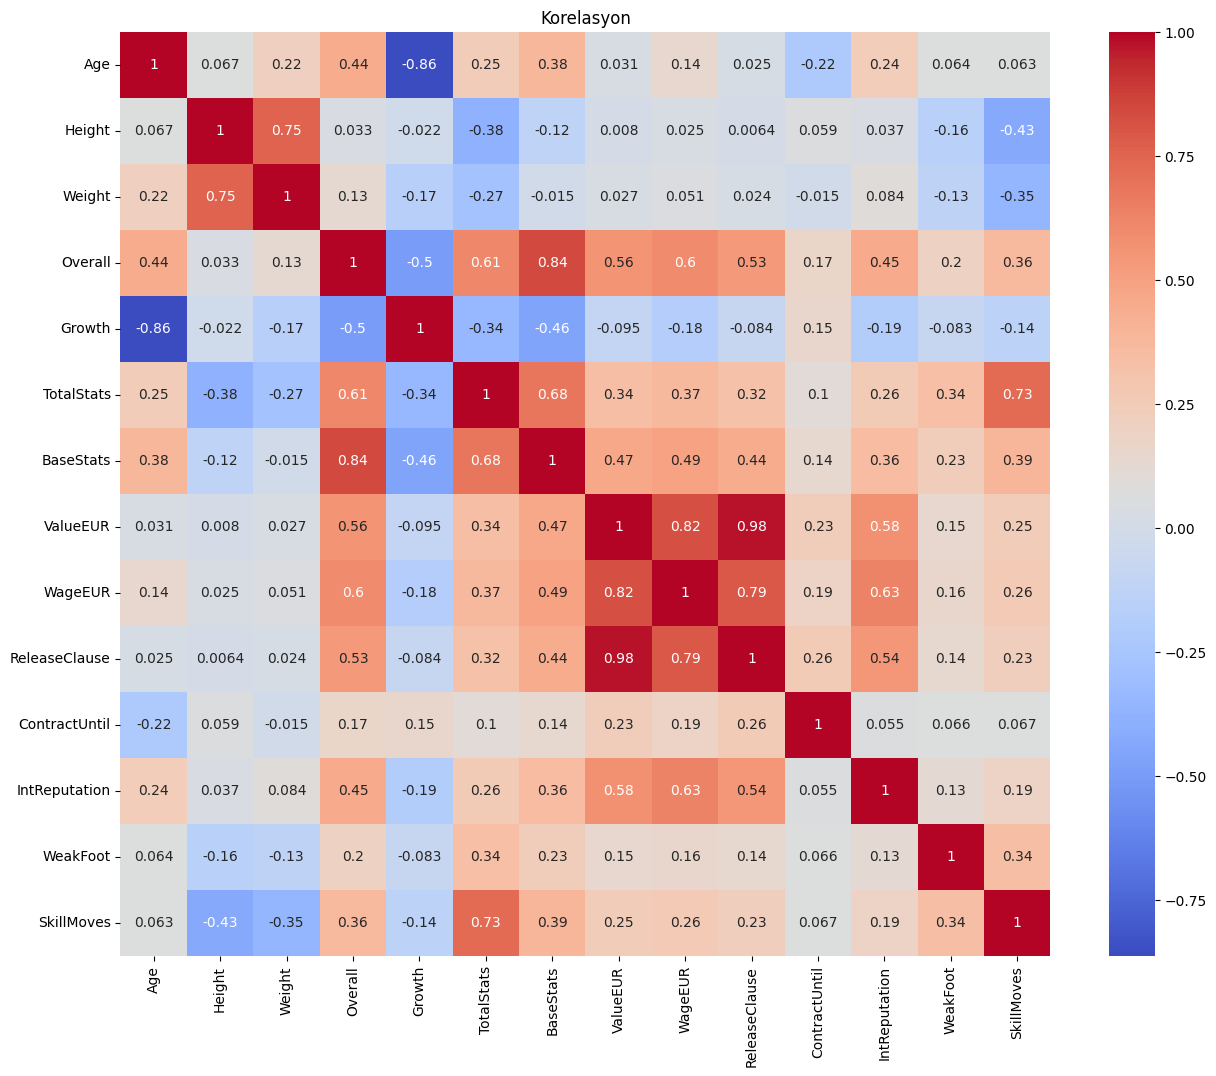

In [12]:
corr = numeric_cols.corr()

plt.figure(figsize=(15,12))
sns.heatmap (corr , cmap="coolwarm" , annot=True)
plt.title("Korelasyon")
plt.show()

In [13]:
df.drop("ReleaseClause" , inplace = True , axis = 1)

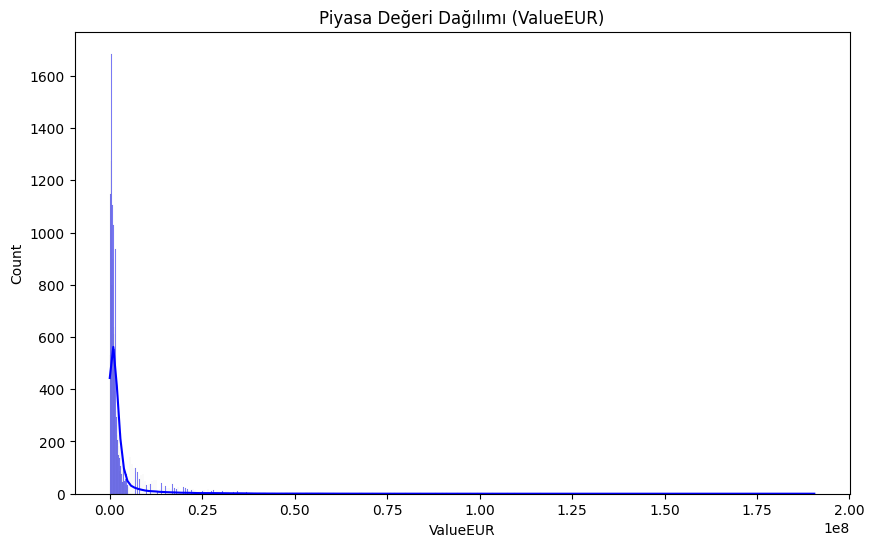

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(df['ValueEUR'], kde=True,color='blue')
plt.title('Piyasa Değeri Dağılımı (ValueEUR)')
plt.show()

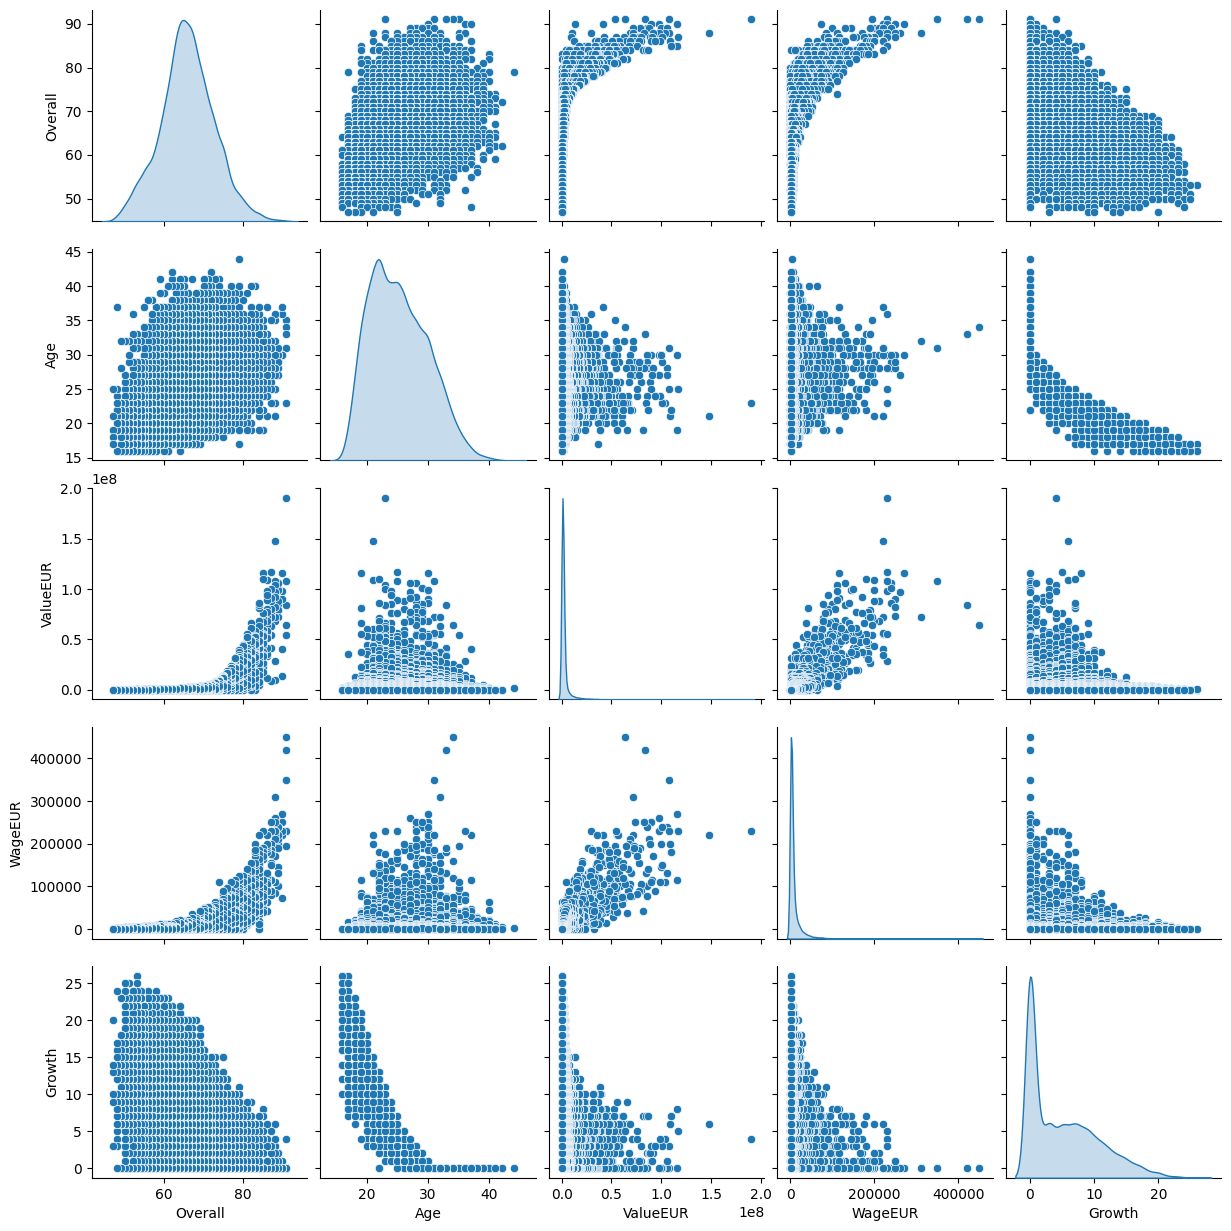

In [15]:
important_cols = ['Overall', 'Age', 'ValueEUR', 'WageEUR', 'Growth']
sns.pairplot(df[important_cols], diag_kind='kde')
plt.show()

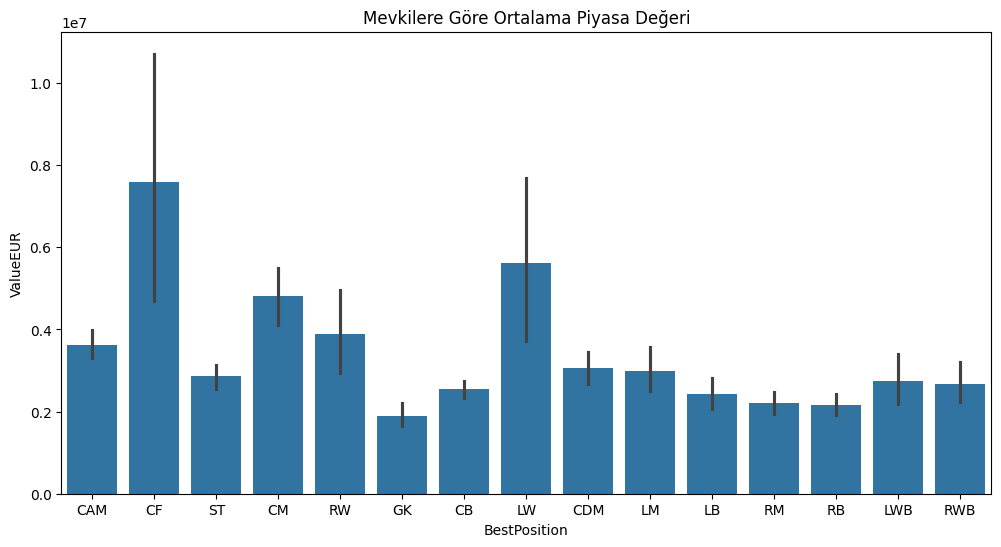

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(x='BestPosition', y='ValueEUR', data=df)
plt.title('Mevkilere Göre Ortalama Piyasa Değeri')
plt.show()

In [17]:
cat_cols = df.select_dtypes(include=["object"])
cat_cols

,Nationality,Positions,BestPosition,Club,ClubPosition,NationalTeam,PreferredFoot,AttackingWorkRate,DefensiveWorkRate
0,Argentina,RW,CAM,Paris Saint-Germain,RW,Argentina,Left,Low,Low
1,France,"CF,ST",CF,Real Madrid CF,CF,France,Right,Medium,Medium
2,Poland,ST,ST,FC Barcelona,ST,Poland,Right,High,Medium
3,Belgium,"CM,CAM",CM,Manchester City,CM,Belgium,Right,High,High
4,France,"ST,LW",ST,Paris Saint-Germain,ST,France,Right,High,Low
...,...,...,...,...,...,...,...,...,...
18534,Republic of Ireland,"ST,RM",CAM,Sligo Rovers,RES,Not in team,Right,Medium,Medium
18535,China PR,CDM,CDM,Guangzhou FC,SUB,Not in team,Right,Medium,Medium
18536,Northern Ireland,CM,RM,Derry City,SUB,Not in team,Right,High,Medium
18537,Republic of Ireland,CB,CB,Derry City,SUB,Not in team,Right,Medium,Medium


In [18]:
for col in cat_cols:
    print(f"{col}: {df[col].nunique()} farklı değer ")

Nationality: 160 farklı değer 
Positions: 693 farklı değer 
BestPosition: 15 farklı değer 
Club: 679 farklı değer 
ClubPosition: 19 farklı değer 
NationalTeam: 36 farklı değer 
PreferredFoot: 2 farklı değer 
AttackingWorkRate: 3 farklı değer 
DefensiveWorkRate: 3 farklı değer 


# Feature Encoding

In [19]:
# ManuelMapping --> DefensiveWorkRate , AttackingWorkRate , PreferredFoot , NationalTeam ,Positions
# OHE --> BestPosition , ClubPosition 
# TargetEncoding --> Nationality , Club

log transformation